# FitzHugh–Nagumo model (ODE) solved with PINNs in JAX

Same model as `FitzHugh-Nagumo-RK45.ipynb`:

$$
\frac{dv}{dt} = v - \frac{v^3}{3} - w + I_{\text{ext}}, \qquad
\frac{dw}{dt} = \frac{1}{\tau}\,\big(v + a - b\,w\big)
$$

- $v$: membrane potential (fast variable)
- $w$: recovery variable (slow variable)

**PINN setup**

- A single MLP $\mathcal{N}_\theta : [-1,1] \to \mathbb{R}^2$ (Equinox), with time normalised as $s = (t - t_0)/T$, $T = t_{\text{final}} - t_0$.
- Initial conditions imposed as a **hard constraint**:
  $\;\big(v, w\big)(t) = \big(v_0, w_0\big) + s\,\mathcal{N}_\theta(2s - 1)$.
- Loss = mean squared ODE residual on collocation points (time derivative via forward-mode `jax.jvp`).
- Optimiser: **SSBroyden** (self-scaled Broyden quasi-Newton with Zoom line search) from
  [`ssbroyden_optimistix`](https://github.com/IvanBioli/ssbroyden_jax), built on Optimistix.
- **Time curriculum**: plain training on the whole interval settles on a wrong, non-causal solution
  (small residual, but ~90% relative error). Instead the collocation window $[t_0, t_0 + T_k]$ grows
  step by step, warm-starting SSBroyden from the previous stage. The network and its time normalisation
  stay the same throughout.

Run with the **`optimistix_env`** kernel.

## Parameters (edit here)

In [ ]:
# ---------------- ODE parameters ----------------
a     = 0.7     # recovery offset
b     = 0.8     # recovery damping
tau   = 12.5    # time-scale separation (w is slower for larger tau)
I_ext = 0.5     # external stimulus current

# ---------------- Initial conditions ----------------
v0 = -1.0
w0 = 1.0

# ---------------- Time domain ----------------
t0      = 0.0
t_final = 50.0     # shorter horizon than RK45 notebook (200)

# ---------------- PINN settings ----------------
layer_sizes = [1, 40, 40, 40, 2]   # input: normalised time, output: (v, w)
N_col       = 2000                 # collocation points on the full interval [t0, t_final]
seed        = 1234

# ---------------- Curriculum / optimiser settings ----------------
n_stages        = 10      # window grows as t0 + T*k/n_stages, k = 1..n_stages
maxiter_stage   = 1000    # SSBroyden iterations per stage
rtol = atol     = 1e-14   # solver tolerances (tiny: in practice stop on maxiter)

# ---------------- Evaluation ----------------
n_eval = 5000             # points for comparison with the reference solution

## Imports and JAX configuration

In [11]:
import sys
import time
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"   # or "1" to use the second GPU

# ssbroyden_optimistix is not a package: add its folder to the path
sys.path.insert(0, "/home/pmzib/ssbroyden_optimistix")

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jax import random, vmap
from scipy.integrate import solve_ivp

from optimistix_wrapper import run_optimization
from ssbrodyen_family import SSBroyden, Zoom

jax.config.update("jax_enable_x64", True)   # quasi-Newton methods need double precision
print("JAX devices:", jax.devices())

JAX devices: [CudaDevice(id=0)]


## Reference solution (RK45)

In [12]:
def fitzhugh_nagumo(t, y, a, b, tau, I_ext):
    v, w = y
    dv = v - v**3 / 3.0 - w + I_ext
    dw = (v + a - b * w) / tau
    return [dv, dw]


ref = solve_ivp(
    fitzhugh_nagumo,
    t_span=(t0, t_final),
    y0=[v0, w0],
    method="RK45",
    args=(a, b, tau, I_ext),
    rtol=1e-10,
    atol=1e-12,
    dense_output=True,
)
print(ref.message)

t_eval = np.linspace(t0, t_final, n_eval)
v_ref, w_ref = ref.sol(t_eval)

The solver successfully reached the end of the integration interval.


## PINN model

The network sees the normalised time $2s - 1 \in [-1, 1]$. The output is multiplied by $s$, so
$(v, w)(t_0) = (v_0, w_0)$ holds exactly for any weights.

In [13]:
class MLP(eqx.Module):
    layers: list

    def __init__(self, layer_sizes, *, key):
        keys = random.split(key, len(layer_sizes) - 1)
        self.layers = [
            eqx.nn.Linear(n_in, n_out, key=k)
            for n_in, n_out, k in zip(layer_sizes[:-1], layer_sizes[1:], keys)
        ]

    def __call__(self, x):
        for layer in self.layers[:-1]:
            x = jnp.tanh(layer(x))
        return self.layers[-1](x)


net = MLP(layer_sizes, key=random.PRNGKey(seed))
init_params, static = eqx.partition(net, eqx.is_array)
n_params = sum(p.size for p in jax.tree_util.tree_leaves(init_params))
print(f"Trainable parameters: {n_params}")

T  = t_final - t0
u0 = jnp.array([v0, w0])


def u(params, t):
    # PINN solution (v, w) at scalar time t, with hard-constrained initial condition.
    s = (t - t0) / T
    nn = eqx.combine(params, static)
    return u0 + s * nn(jnp.atleast_1d(2.0 * s - 1.0))


def rhs(uu):
    v, w = uu
    return jnp.array([v - v**3 / 3.0 - w + I_ext, (v + a - b * w) / tau])


def residual(params, t):
    # ODE residual du/dt - f(u) at scalar time t (du/dt by forward-mode AD).
    uu, du_dt = jax.jvp(lambda tt: u(params, tt), (t,), (1.0,))
    return du_dt - rhs(uu)


v_u        = jax.jit(vmap(u, (None, 0)))
v_residual = vmap(residual, (None, 0))


def make_loss(t_col):
    def loss(params):
        return jnp.mean(v_residual(params, t_col) ** 2)
    return loss


def rel_l2_errors(params):
    # Relative L2 errors of (v, w) on [t0, t_final] against the RK45 reference.
    U = np.asarray(v_u(params, jnp.asarray(t_eval)))
    return (np.linalg.norm(U[:, 0] - v_ref) / np.linalg.norm(v_ref),
            np.linalg.norm(U[:, 1] - w_ref) / np.linalg.norm(w_ref))

Trainable parameters: 8578


## Training: SSBroyden with a growing time window

Stage $k$ uses equispaced collocation points on $[t_0, t_0 + kT/n_{\text{stages}}]$, with the same density
as $N_{\text{col}}$ on the full interval. Each stage starts from the previous stage's weights. The errors
printed below are always measured on the **full** interval $[t_0, t_{\text{final}}]$, so they are large until
the last stage, when the window covers everything.

In [14]:
params  = init_params
history = {"iter": [], "loss": [], "err_v": [], "err_w": []}
stage_ends = []   # cumulative iteration count at the end of each stage
log_every  = 10
it_offset  = 0
t_start    = time.time()

for k in range(1, n_stages + 1):
    T_k   = T * k / n_stages
    t_col = jnp.linspace(t0, t0 + T_k, int(N_col * k / n_stages))
    loss_k = make_loss(t_col)

    def callback(it, p, state, cur_loss, _off=it_offset):
        if it % log_every == 0:
            history["iter"].append(_off + it)
            history["loss"].append(cur_loss)
        return False

    solver = SSBroyden(rtol=rtol, atol=atol, search=Zoom(initial_guess_strategy="increase"))
    res = run_optimization(solver, loss_k, params, maxiter=maxiter_stage,
                           callback=callback, verbose=False)
    params     = res.params
    it_offset += res.num_iters
    stage_ends.append(it_offset)

    ev, ew = rel_l2_errors(params)
    history["err_v"].append(ev)
    history["err_w"].append(ew)
    print(f"stage {k:2d} | window [{t0:.0f}, {t0 + T_k:5.1f}] | iters {res.num_iters:5d} "
          f"| loss {res.final_loss:.3e} | rel L2 err (full interval) v {ev:.2e}, w {ew:.2e} "
          f"| {time.time() - t_start:6.1f} s")

print(f"\nTotal SSBroyden iterations: {it_offset},  wall time: {time.time() - t_start:.1f} s")

stage  1 | window [0,   5.0] | iters  1000 | loss 2.153e-12 | rel L2 err (full interval) v 4.80e+01, w 6.69e+01 |   29.4 s
stage  2 | window [0,  10.0] | iters  1000 | loss 4.476e-13 | rel L2 err (full interval) v 4.87e+01, w 6.84e+01 |   60.7 s
stage  3 | window [0,  15.0] | iters  1000 | loss 2.835e-13 | rel L2 err (full interval) v 4.86e+01, w 6.79e+01 |   88.9 s
stage  4 | window [0,  20.0] | iters  1000 | loss 3.744e-13 | rel L2 err (full interval) v 4.93e+01, w 6.67e+01 |  120.4 s
stage  5 | window [0,  25.0] | iters  1000 | loss 6.429e-10 | rel L2 err (full interval) v 5.05e+01, w 5.87e+01 |  152.1 s
stage  6 | window [0,  30.0] | iters  1000 | loss nan | rel L2 err (full interval) v nan, w nan |  175.2 s
stage  7 | window [0,  35.0] | iters  1000 | loss nan | rel L2 err (full interval) v nan, w nan |  198.1 s
stage  8 | window [0,  40.0] | iters  1000 | loss nan | rel L2 err (full interval) v nan, w nan |  220.8 s
stage  9 | window [0,  45.0] | iters  1000 | loss nan | rel L2 e

## PINN solution vs RK45

Relative L2 error:  v = nan,  w = nan
Max abs error:      v = nan,  w = nan


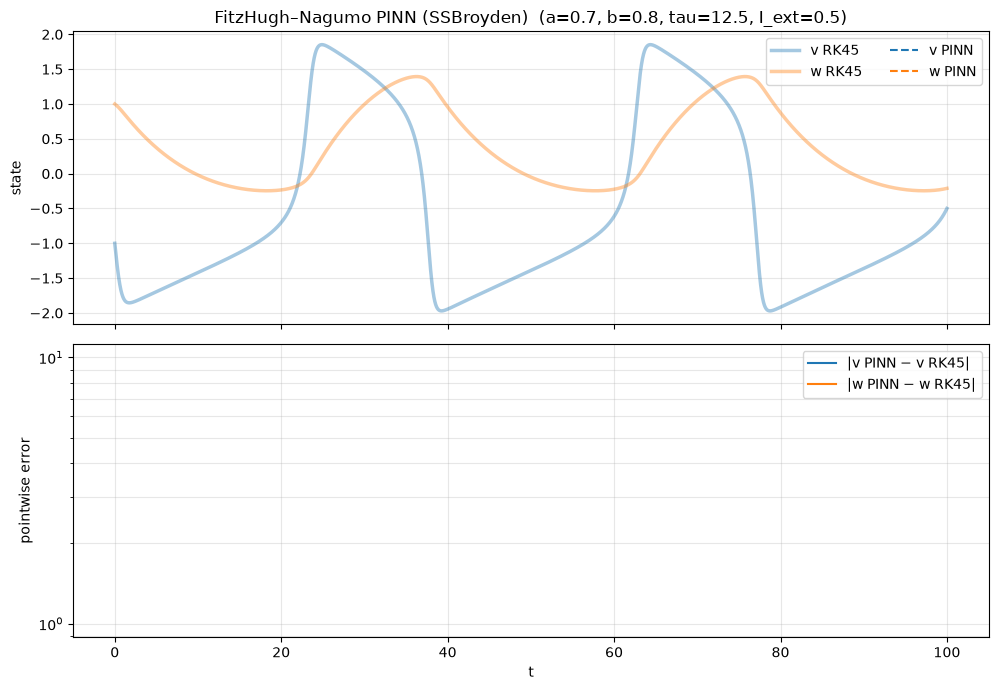

In [15]:
U_pinn = np.asarray(v_u(params, jnp.asarray(t_eval)))
v_pinn, w_pinn = U_pinn[:, 0], U_pinn[:, 1]
err_v, err_w = rel_l2_errors(params)
print(f"Relative L2 error:  v = {err_v:.3e},  w = {err_w:.3e}")
print(f"Max abs error:      v = {np.abs(v_pinn - v_ref).max():.3e},  w = {np.abs(w_pinn - w_ref).max():.3e}")

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
ax = axes[0]
ax.plot(t_eval, v_ref, color="tab:blue", lw=2.5, alpha=0.4, label="v RK45")
ax.plot(t_eval, w_ref, color="tab:orange", lw=2.5, alpha=0.4, label="w RK45")
ax.plot(t_eval, v_pinn, "--", color="tab:blue", label="v PINN")
ax.plot(t_eval, w_pinn, "--", color="tab:orange", label="w PINN")
ax.set_ylabel("state")
ax.set_title(f"FitzHugh–Nagumo PINN (SSBroyden)  (a={a}, b={b}, tau={tau}, I_ext={I_ext})")
ax.legend(ncol=2)
ax.grid(alpha=0.3)

ax = axes[1]
ax.semilogy(t_eval, np.abs(v_pinn - v_ref), label="|v PINN − v RK45|")
ax.semilogy(t_eval, np.abs(w_pinn - w_ref), label="|w PINN − w RK45|")
ax.set_xlabel("t")
ax.set_ylabel("pointwise error")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## Training history

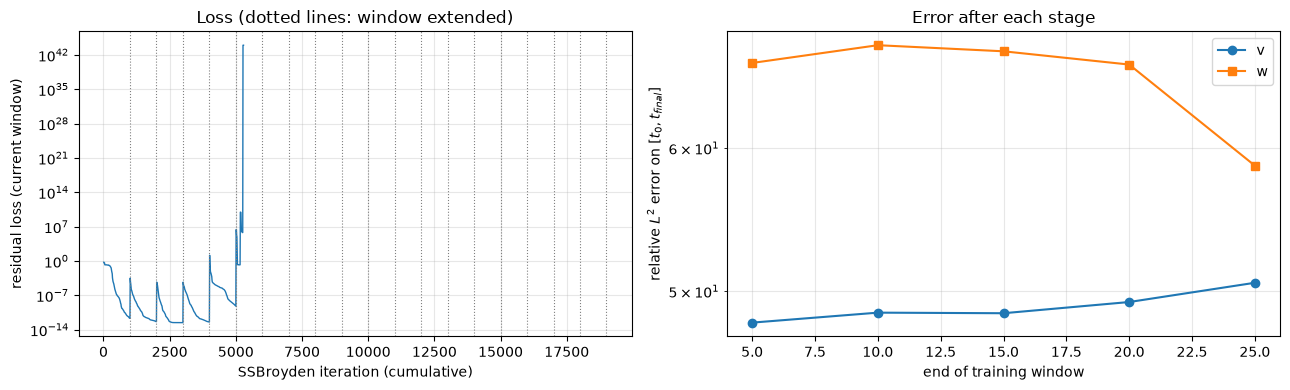

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
ax.semilogy(history["iter"], history["loss"], lw=1)
for s in stage_ends[:-1]:
    ax.axvline(s, color="gray", ls=":", lw=0.8)
ax.set_xlabel("SSBroyden iteration (cumulative)")
ax.set_ylabel("residual loss (current window)")
ax.set_title("Loss (dotted lines: window extended)")
ax.grid(alpha=0.3, which="both")

ax = axes[1]
windows = [t0 + T * k / n_stages for k in range(1, n_stages + 1)]
ax.semilogy(windows, history["err_v"], "o-", label="v")
ax.semilogy(windows, history["err_w"], "s-", label="w")
ax.set_xlabel("end of training window")
ax.set_ylabel(r"relative $L^2$ error on $[t_0, t_{final}]$")
ax.set_title("Error after each stage")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## Phase plane

Nullclines: $w = v - v^3/3 + I_{\text{ext}}$ ($\dot v = 0$) and $w = (v + a)/b$ ($\dot w = 0$).

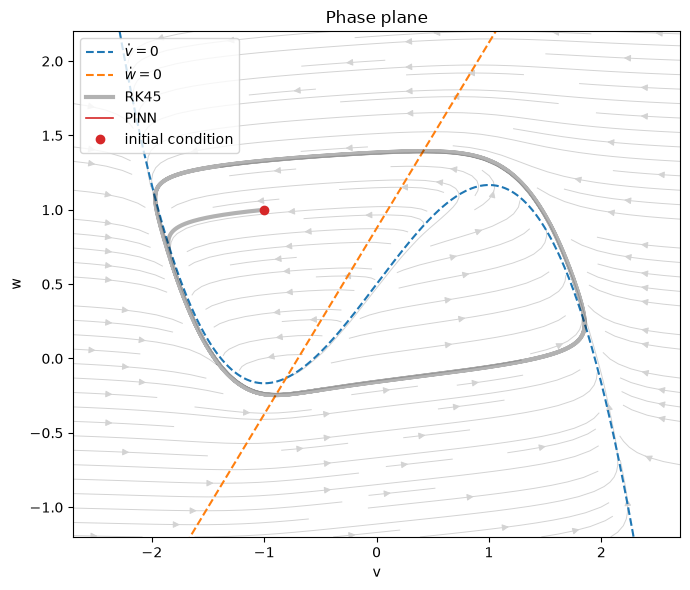

In [17]:
v_min, v_max = min(v_ref.min(), -2.5) - 0.2, max(v_ref.max(), 2.5) + 0.2
w_min, w_max = min(w_ref.min(), -1.0) - 0.2, max(w_ref.max(), 2.0) + 0.2

vv = np.linspace(v_min, v_max, 400)
V, W = np.meshgrid(np.linspace(v_min, v_max, 25), np.linspace(w_min, w_max, 25))
dV, dW = fitzhugh_nagumo(0, [V, W], a, b, tau, I_ext)

fig, ax = plt.subplots(figsize=(7, 6))
ax.streamplot(V, W, dV, dW, color="lightgray", density=1.2, linewidth=0.7)
ax.plot(vv, vv - vv**3 / 3 + I_ext, "--", label=r"$\dot v = 0$")
ax.plot(vv, (vv + a) / b, "--", label=r"$\dot w = 0$")
ax.plot(v_ref, w_ref, color="k", lw=3, alpha=0.3, label="RK45")
ax.plot(v_pinn, w_pinn, color="tab:red", lw=1.2, label="PINN")
ax.plot(v0, w0, "o", color="tab:red", label="initial condition")
ax.set_xlim(v_min, v_max)
ax.set_ylim(w_min, w_max)
ax.set_xlabel("v")
ax.set_ylabel("w")
ax.set_title("Phase plane")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Save results

In [18]:
# np.savez("fitzhugh_nagumo_pinn_solution.npz",
#          t=t_eval, v=v_pinn, w=w_pinn, v_ref=v_ref, w_ref=w_ref)
# eqx.tree_serialise_leaves("fitzhugh_nagumo_pinn_params.eqx", params)